# 01 - Preprocessing (Adult Dataset)

This notebook loads the Adult dataset, performs preprocessing, and saves a cached, model-ready bundle for later notebooks.

**Sensitive attribute:** Gender (`sex`)  
**Target:** Income > 50K

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from src.data_utils import load_adult_raw, prepare_adult_dataset, save_dataset_stats
from src.config import DATA_DIR, TARGET_COL, SENSITIVE_COL

In [8]:
df = load_adult_raw()
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [9]:
stats = {
    "n_rows": int(df.shape[0]),
    "n_cols": int(df.shape[1]),
    "class_distribution": df[TARGET_COL].value_counts().to_dict(),
    "gender_distribution": df[SENSITIVE_COL].value_counts().to_dict(),
}
stats

{'n_rows': 45222,
 'n_cols': 15,
 'class_distribution': {'<=50K': 34014, '>50K': 11208},
 'gender_distribution': {'Male': 30527, 'Female': 14695}}

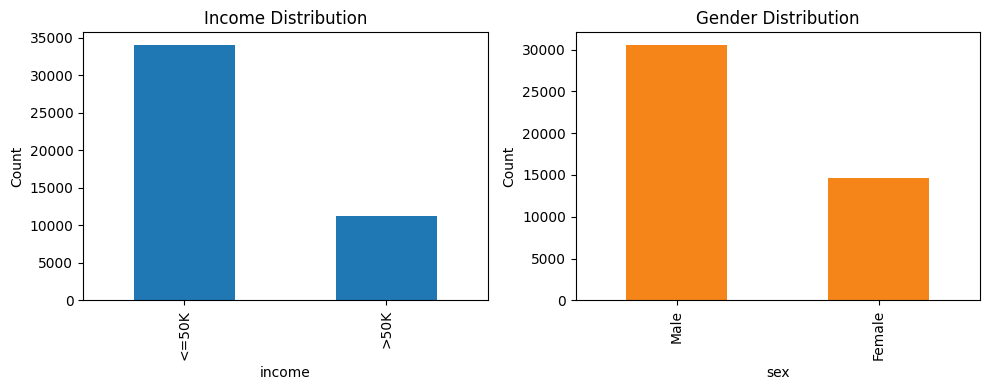

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df[TARGET_COL].value_counts().plot(kind="bar", ax=axes[0], title="Income Distribution")
df[SENSITIVE_COL].value_counts().plot(kind="bar", ax=axes[1], title="Gender Distribution", color="#F58518")
axes[0].set_ylabel("Count")
axes[1].set_ylabel("Count")
plt.tight_layout()

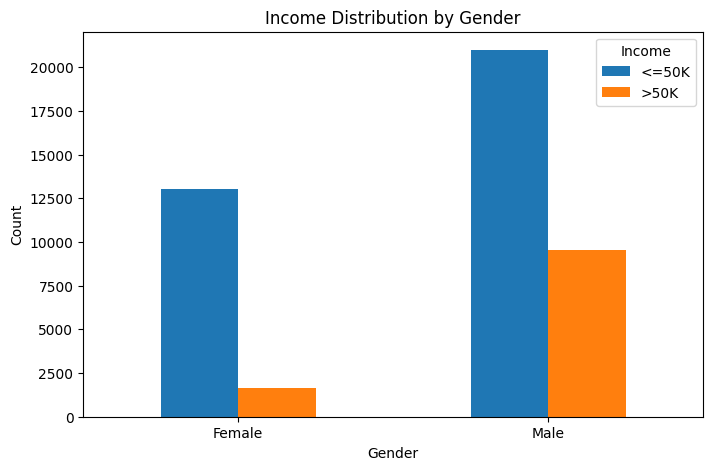

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Income distribution by gender
income_gender = pd.crosstab(df[SENSITIVE_COL], df[TARGET_COL])

# Plot
income_gender.plot(kind="bar", figsize=(8,5))

plt.title("Income Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.legend(title="Income")
plt.show()

In [12]:
bundle = prepare_adult_dataset(force=True)
bundle.X_train.shape, bundle.X_test.shape

((36177, 102), (9045, 102))

In [13]:
stats_path = DATA_DIR / "results" / "dataset_stats.json"
save_dataset_stats(stats, stats_path)
stats_path

WindowsPath('C:/Users/ASUS/OneDrive/Desktop/fair_ml/data/results/dataset_stats.json')

## Discussion and Analysis of Preprocessing

The preprocessing stage is a critical component of fairness-aware machine learning because the quality and distribution of the data strongly influence both predictive performance and fairness outcomes.

The Adult Income dataset was used in this project, where the objective is to predict whether an individual's annual income exceeds \$50K. Gender was selected as the sensitive attribute for fairness analysis.

---

### Dataset Characteristics

The dataset contains both:
- numerical features (such as age and hours-per-week),
- and categorical features (such as occupation, education, and marital status).

Since many machine learning models require numerical inputs, categorical variables were transformed using one-hot encoding.

In addition, feature scaling was applied to normalize numerical features and improve model stability during training.

---

### Class Imbalance

The income distribution analysis revealed that the dataset is imbalanced:

- the majority of samples belong to the `<=50K` class,
- while a smaller portion belongs to the `>50K` class.

This imbalance is important because classifiers trained on imbalanced datasets may become biased toward the majority class, potentially affecting fairness and predictive performance.

---

### Sensitive Attribute Distribution

The gender distribution analysis showed that:
- male samples are more frequent than female samples in the dataset.

This imbalance is particularly important in fairness-aware learning because models may generalize differently across sensitive groups when one group dominates the training data.

---

### Income Distribution by Gender

The income-by-gender visualization revealed noticeable disparities between sensitive groups.

The proportion of individuals earning `>50K` differs significantly across genders, suggesting that the dataset already contains demographic and societal biases.

This observation strongly motivates the need for fairness-aware learning approaches.

---

### Preprocessing Pipeline

The preprocessing pipeline included:

1. handling categorical variables,
2. one-hot encoding,
3. feature scaling,
4. train-test splitting,
5. extraction of the sensitive attribute.

The processed dataset is now suitable for:
- STL (Single Task Learning),
- ITL (Independent Task Learning),
- fairness-aware optimization,
- and Multitask Learning experiments.

---

## Key Insight

The preprocessing analysis demonstrates that:
- the Adult dataset contains both class imbalance and sensitive-group imbalance,
- income distribution differs across genders,
- and fairness concerns are already present in the raw data before model training begins.

These observations justify the need for fairness-aware machine learning methods in the later stages of the project.

## Notes
- The processed dataset is cached for reuse in later notebooks.
- One-hot encoding is applied to categorical features and numeric features are standardized.
- The sensitive attribute is extracted but removed from features during modeling.